In [58]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from tqdm.autonotebook import tqdm
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


In [59]:
STN_DATA_path_PD = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_PD.yaml')
STN_DATA_path_std_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_std_DBS.yaml')
STN_DATA_path_sector_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_sector_DBS.yaml')
DEL_LIM_ARR = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0] #[0.1, 0.2, 0.5, 1.0]
FILE_PATHS = [STN_DATA_path_PD, STN_DATA_path_std_DBS, STN_DATA_path_sector_DBS]
TYPE = ['PD', 'STD_DBS', 'SECTOR_DBS']
LAT_STRENGTH = 0.0275
VAR_ARR = [0.01, 0.04, 0.39] 


In [60]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'prob_reversal_learning', 'params.yaml')
params = load_yaml(yaml_path)


In [61]:
TRIALS = params['TRIALS']
EPOCHS = params['EPOCHS']
BINS = params['NUM_BINS']
LR = params['LR']
NUM_ARMS = params['NUM_ARMS']
SCALING_FACTOR = params['SCALING_FACTOR']
TIME_STAMP_CHANGE = params['TIME_STAMP_CHANGE']
STATIONARY = False
BIN_SIZE = TRIALS//BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE



# Define reward values for each arm
REWARD_VALUES = np.array([10, 10])/SCALING_FACTOR
REWARD_STD = np.array([2, 2])/SCALING_FACTOR

# Define initial probabilities for each arm
INITIAL_PROBS = np.array([0.8, 0.2])

# Define changed reward values (after time_stamp_change)
REWARD_VALUES_CHANGED = np.array([10, 10])/SCALING_FACTOR
REWARD_STD_CHANGED = np.array([2, 2])/SCALING_FACTOR

# Define changed probabilities (after time_stamp_change)
CHANGED_PROBS = np.array([0.2, 0.8])

# Set which parameters to change: 'reward', 'probability', or 'both' : Can change probs or rewards alone or both
CHANGE_TYPE = 'probability'



BEST_ARM_BEFORE = 0
BEST_ARM_AFTER = 1

BEST_ARM = torch.zeros((EPOCHS,TRIALS), dtype=int)
BEST_ARM[:,:TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
BEST_ARM[:,TIME_STAMP_CHANGE:] = BEST_ARM_AFTER  



def process_prob(arm_chosen_monitor:list):  
    # Computing Accuracy
    prob_optimal = torch.zeros((EPOCHS, BINS))

    for i in range(BINS):
        start, end = i * BIN_SIZE, (i + 1) * BIN_SIZE
        correct_choices = torch.sum(arm_chosen_monitor[:, start:end] == BEST_ARM[:,start:end], axis = 1)
        prob_optimal[:, i] = (correct_choices / BIN_SIZE)

    prob_optimal_per_bin = torch.mean(prob_optimal,axis = 0)

    return prob_optimal_per_bin
    


In [62]:
env = ProbReversalEnv(
    num_arms = NUM_ARMS,
    mean_reward = REWARD_VALUES,
    std = REWARD_STD,
    probabilities = INITIAL_PROBS,
    mean_rew_change = REWARD_VALUES_CHANGED,
    std_change = REWARD_STD_CHANGED,
    probabilities_change = CHANGED_PROBS,
    time_stamp_change = TIME_STAMP_CHANGE,
    change_type = CHANGE_TYPE)


In [63]:
ARM_MONITOR = defaultdict(dict)
NUM_ARM_PICKS_MONITOR = defaultdict(dict)
DP_MONITOR = defaultdict(dict)
IP_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)
OPTIMAL_CHOICE_MONITOR = defaultdict(dict)
ACTUAL_CHOICE_MONITOR = defaultdict(dict)
PROB_OPTIMAL_MONITOR = defaultdict(dict)
LAST_BIN_PROB_MONITOR = defaultdict(dict)
PRE_CHANGE_PROB_MONITOR = defaultdict(dict)

In [64]:
t = 0
for file_path in tqdm(FILE_PATHS):
    print(f'Running: {TYPE[t]}')
    args = load_yaml(file_path)
    args['lat_strength_stn'] = LAT_STRENGTH
    save_temp_path = os.path.join(project_root, 'temp', 'temp.yaml')
    save_yaml(args, save_temp_path)
    for del_lim in DEL_LIM_ARR:
        reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, arm_tracker_full= train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = save_temp_path, 
                                                      d1_amp=0.82, #0.35,
                                                      d2_amp=0.015, #0.003,#0.0035, #0.0029,
                                                      gpi_threshold=0.3,
                                                      max_gpi_iters=50,
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = 0,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)
        
    
        ARM_MONITOR[TYPE[t]][del_lim] = arm_chosen_monitor
        REWARD_MONITOR[TYPE[t]][del_lim] = reward_monitor
        ARM_TRACKER[TYPE[t]][del_lim] = arm_tracker_full

        ACTUAL_CHOICE_ARRAY = np.array(ARM_MONITOR[TYPE[t]][del_lim])
        PROB = process_prob(ARM_MONITOR[TYPE[t]][del_lim]) 
        last_bin_prob = PROB[-1]
        pre_change_prob = PROB[4]
        ACTUAL_CHOICE_MONITOR[TYPE[t]][del_lim] = ACTUAL_CHOICE_ARRAY
        PROB_OPTIMAL_MONITOR[TYPE[t]][del_lim] = PROB
        LAST_BIN_PROB_MONITOR[TYPE[t]][del_lim] = last_bin_prob
        PRE_CHANGE_PROB_MONITOR[TYPE[t]][del_lim] = pre_change_prob
        print(f'Type: {TYPE[t]} and del_lim = {del_lim}: : last bin prob of optimal arm = {last_bin_prob}')
    t +=1 


  0%|          | 0/3 [00:00<?, ?it/s]

Running: PD
Running STN-GPe system


  0%|          | 0/120000 [00:00<?, ?it/s]

tensor(0.0168, dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(0.0168, dtype=torch.float64)


  0%|          | 0/100 [00:00<?, ?it/s]

...

Type: SECTOR_DBS and del_lim = 0.5: : last bin prob of optimal arm = 0.4410000741481781
Running STN-GPe system


  0%|          | 0/120000 [00:00<?, ?it/s]

tensor(0.4988, dtype=torch.float64)
tensor(1.0000, dtype=torch.float64) tensor(0.4980, dtype=torch.float64)


  0%|          | 0/100 [00:00<?, ?it/s]

Type: SECTOR_DBS and del_lim = 1.0: : last bin prob of optimal arm = 0.43800002336502075


In [68]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
Last_bin_Probs_PD = [LAST_BIN_PROB_MONITOR[TYPE[0]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_Probs_std_DBS = [LAST_BIN_PROB_MONITOR[TYPE[1]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_Probs_sector_DBS = [LAST_BIN_PROB_MONITOR[TYPE[2]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]

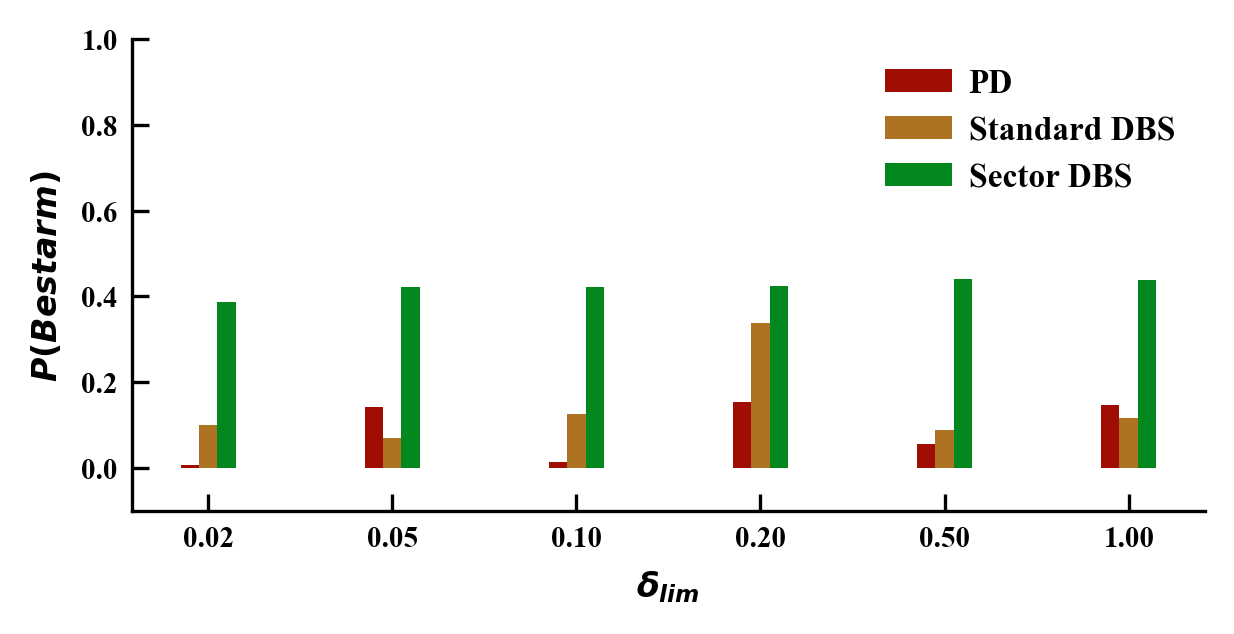

In [69]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}

plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Last_bin_Probs_PD + np.abs(np.random.randn(len(Last_bin_Probs_PD))*0.01), width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Last_bin_Probs_std_DBS+ np.abs(np.random.randn(len(Last_bin_Probs_std_DBS))*0.01), width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Last_bin_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR_FILTERED], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.ylim(-0.1, 1)
plt.show()

In [67]:
# # saving pickle with lat name
# data = {'DEL_LIM_ARR': DEL_LIM_ARR,
#         'TYPE': TYPE,
#         'ARM_MONITOR': ARM_MONITOR,
#         'LAT_STRENGTH': LAT_STRENGTH,
#         'ARM_TRACKER': ARM_TRACKER,
#         'LAST_BIN_PROB_MONITOR': LAST_BIN_PROB_MONITOR,
#         'PROB_OPTIMAL_MONITOR': PROB_OPTIMAL_MONITOR,
#         'PRE_CHANGE_PROB_MONITOR': PRE_CHANGE_PROB_MONITOR,
#         'REWARD_MONITOR': REWARD_MONITOR}
# file_name = 'prob_reversal_learning_data_lat_' + str(LAT_STRENGTH).replace('.', '_') + '.pkl'
# file_path = os.path.join(project_root, 'simulations', 'decision_making_tasks', 'prob_reversal_learning', file_name)

# with open(file_path, 'wb') as f:
#     pickle.dump(data, f)